# Task 3: Clustering Analysis

**Index:**
1. Load Engineered Data
2. K-Means Clustering (K=3)
3. Hierarchical Clustering
4. Gaussian Mixture Models (GMM)
5. Multi-Algorithm Comparison
6. Best Algorithm Analysis

In [11]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import clustering utilities
from src.clustering import (
    apply_kmeans,
    apply_agglomerative,
    apply_gmm,
    evaluate_clustering,
    plot_cluster_scatter,
    plot_algorithm_comparison,
    plot_cluster_size_distribution,
    compare_clusters_to_classes,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Ensure plots directory exists
os.makedirs(os.path.join(project_root, "data", "plots"), exist_ok=True)

## 1. Load Engineered Data

In [12]:
# Load engineered train/val/test data and concatenate to full dataset
features_train = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'))
targets_train = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv')).iloc[:, 0]

features_val = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'))
targets_val = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv')).iloc[:, 0]

features_test = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'))
targets_test = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv')).iloc[:, 0]

# Concatenate to full dataset
X = pd.concat([features_train, features_val, features_test], axis=0, ignore_index=True)
y = pd.concat([targets_train, targets_val, targets_test], axis=0, ignore_index=True)

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

Features shape: (4424, 40)
Target distribution:
Target
0    1421
1     794
2    2209


In [13]:
# Compute PCA 2D projection for visualization
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=2, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)
X_2d = pca.fit_transform(X_scaled)
print(f"PCA 2D projection shape: {X_2d.shape}")

PCA 2D projection shape: (4424, 2)


Three clustering algorithms with distinct assumptions are selected:

1. **K-Means**: Assumes spherical, equal-size clusters. Computationally efficient O(nKt), requires pre-specifying K. We set K=3 based on the known 3-class structure for direct comparison.
2. **Agglomerative Hierarchical**: No need to pre-specify K. Produces a dendrogram showing hierarchical merge structure. Supports multiple linkage methods (ward/complete/average/single).
3. **GMM**: Assumes data comes from a mixture of Gaussians. Provides soft (probabilistic) assignments rather than hard boundaries, better handling overlapping class distributions.

In [14]:
# Apply K-Means with K=3 (known class count)
optimal_k = 3
kmeans_labels, kmeans_model = apply_kmeans(X.values, n_clusters=optimal_k, random_state=42)

In [15]:
# K-Means Evaluation
kmeans_metrics = evaluate_clustering(X.values, kmeans_labels, y.values)
print(f"\nK-Means (K={optimal_k}) Metrics:")
for name, value in kmeans_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# K-Means cluster size distribution
kmeans_cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
kmeans_size_df = pd.DataFrame({
    "Cluster": kmeans_cluster_sizes.index,
    "Count": kmeans_cluster_sizes.values,
    "Percentage": (kmeans_cluster_sizes.values / len(kmeans_labels) * 100).round(1)
})
print("\nK-Means Cluster Size Distribution:")
print(kmeans_size_df.to_string(index=False))

# K-Means cross-tabulation
class_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
kmeans_crosstab = compare_clusters_to_classes(kmeans_labels, y.values)
print("\nK-Means Clusters vs True Classes:")
print(kmeans_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in kmeans_crosstab.index:
    row = kmeans_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")


K-Means (K=3) Metrics:
  silhouette: 0.2421
  silhouette_std: 0.1154
  calinski_harabasz: 1304.4713
  davies_bouldin: 1.5809
  noise_ratio: 0.0000
  adjusted_rand_index: 0.0033
  normalized_mutual_info: 0.0054

K-Means Cluster Size Distribution:
 Cluster  Count  Percentage
       0   1960        44.3
       1   1364        30.8
       2   1100        24.9

K-Means Clusters vs True Classes:
True Class    0    1    2
Cluster                  
0           594  376  990
1           525  187  652
2           302  231  567

Dominant Class per Cluster:
  Cluster 0: Graduate (50.5%)
  Cluster 1: Graduate (47.8%)
  Cluster 2: Graduate (51.5%)


## 3. Hierarchical Clustering

We apply Agglomerative Hierarchical Clustering using Ward linkage, which minimizes the increase in total within-cluster variance at each merge step. The algorithm produces a dendrogram that reveals the hierarchical structure of the data, showing how clusters merge as the distance threshold increases.

Hierarchical Clustering (Ward, K=3) Metrics:
  silhouette: 0.2314
  silhouette_std: 0.1255
  calinski_harabasz: 1226.7587
  davies_bouldin: 1.7040
  noise_ratio: 0.0000
  adjusted_rand_index: 0.0023
  normalized_mutual_info: 0.0043
Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/05_hierarchical_clusters_pca.png


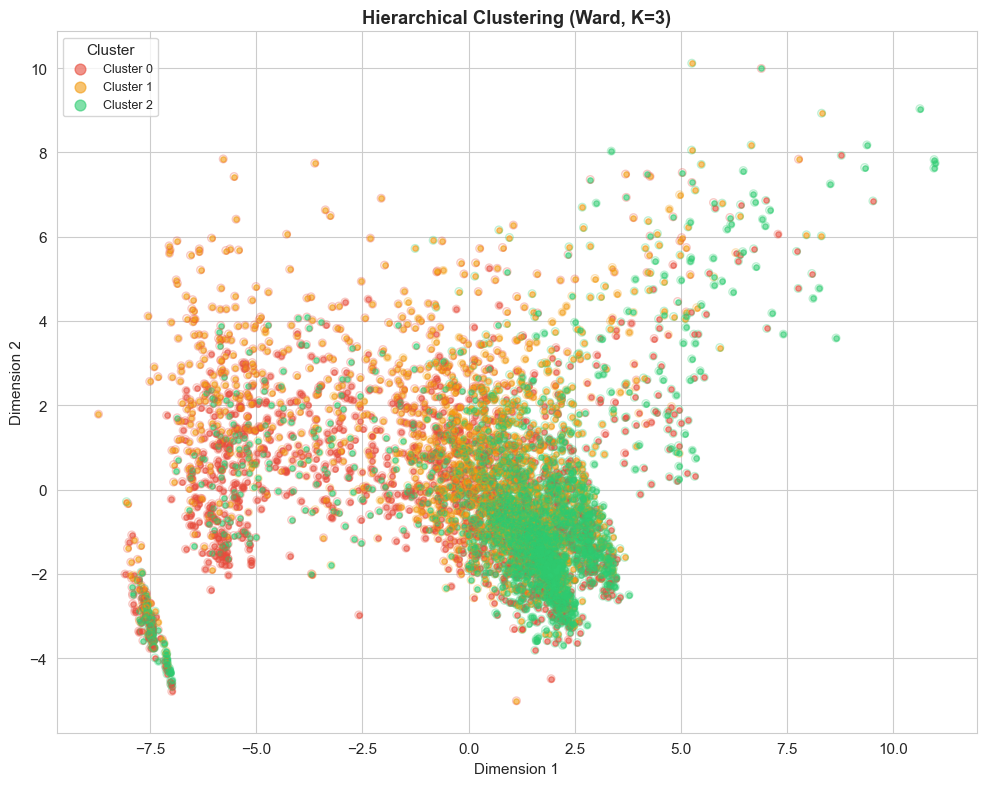

Hierarchical Cluster Size Distribution:
 Cluster  Count  Percentage
       0   1945        44.0
       1   1343        30.4
       2   1136        25.7
Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/03_dendrogram_ward.png


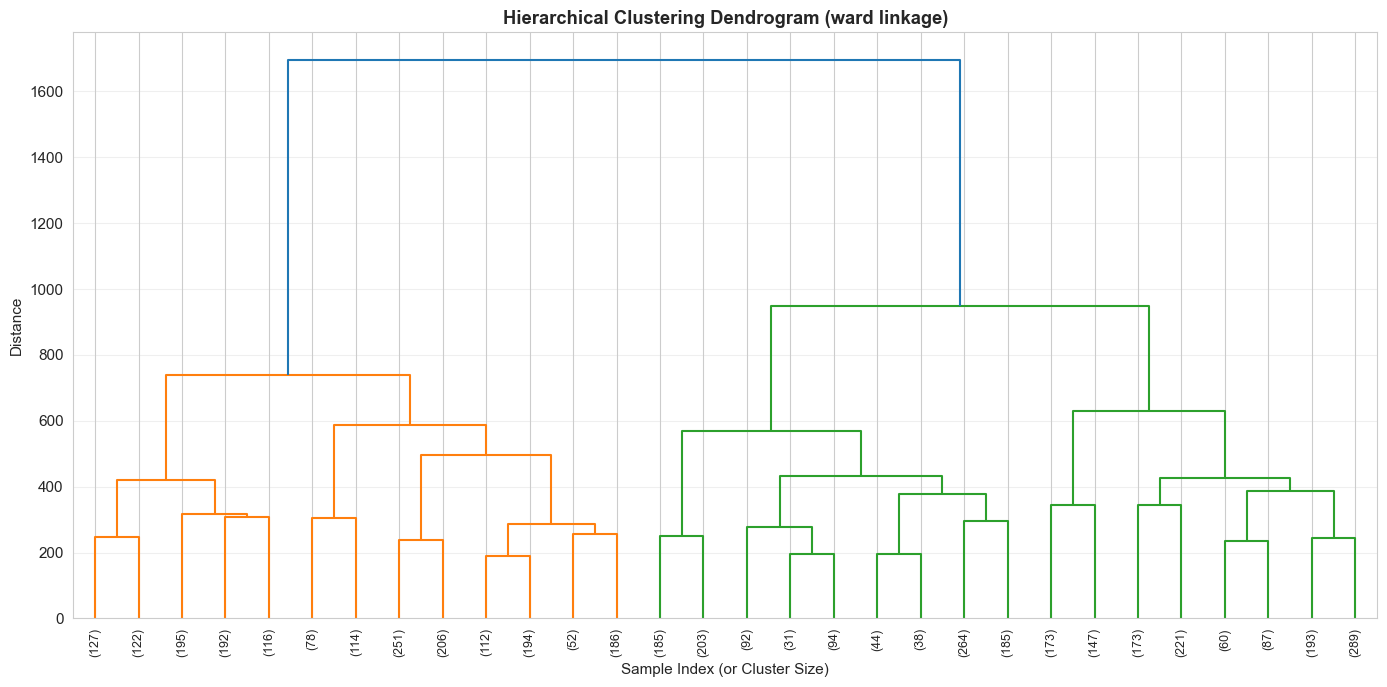


Hierarchical Clusters vs True Classes:
True Class    0    1    2
Cluster                  
0           588  376  981
1           510  189  644
2           323  229  584

Dominant Class per Cluster:
  Cluster 0: Graduate (50.4%)
  Cluster 1: Graduate (48.0%)
  Cluster 2: Graduate (51.4%)

Comparison of Linkage Methods (K=3):
      Method | Silhouette |     CH Index |   DB Index |      ARI
------------------------------------------------------------
        ward |     0.2314 |      1226.76 |     1.7040 |   0.0023
    complete |     0.1291 |       420.47 |     2.1586 |   0.0086
     average |     0.3166 |        37.54 |     1.1090 |  -0.0006
      single |     0.3973 |         5.08 |     0.4261 |  -0.0003


In [16]:
# Hierarchical Clustering with Ward linkage
total = len(kmeans_labels)
agg_labels, agg_model = apply_agglomerative(X.values, n_clusters=3, linkage="ward")
agg_metrics = evaluate_clustering(X.values, agg_labels, y.values)

print("Hierarchical Clustering (Ward, K=3) Metrics:")
for name, value in agg_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot clusters on PCA
save_path = os.path.join(project_root, "data", "plots", "05_hierarchical_clusters_pca.png")
ax = plot_cluster_scatter(X_2d, agg_labels, title="Hierarchical Clustering (Ward, K=3)", y_true=y.values, save_path=save_path)
plt.show()

# Hierarchical cluster size distribution table
agg_cluster_sizes = pd.Series(agg_labels).value_counts().sort_index()
agg_size_df = pd.DataFrame({
    "Cluster": agg_cluster_sizes.index,
    "Count": agg_cluster_sizes.values,
    "Percentage": (agg_cluster_sizes.values / total * 100).round(1)
})
print("Hierarchical Cluster Size Distribution:")
print(agg_size_df.to_string(index=False))

# Hierarchical Clustering Dendrogram (Ward linkage)
from src.clustering import plot_dendrogram
fig = plot_dendrogram(
    X.values,
    method="ward",
    save_path=os.path.join(project_root, "data", "plots", "03_dendrogram_ward.png"),
)
plt.show()

# Hierarchical cross-tabulation
agg_crosstab = compare_clusters_to_classes(agg_labels, y.values)
print("\nHierarchical Clusters vs True Classes:")
print(agg_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in agg_crosstab.index:
    row = agg_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

# Linkage methods comparison
linkage_methods = ["ward", "complete", "average", "single"]
linkage_results = {}

print("\nComparison of Linkage Methods (K=3):")
print(f"{'Method':>12} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10} | {'ARI':>8}")
print("-" * 60)

for method in linkage_methods:
    labels, _ = apply_agglomerative(X.values, n_clusters=3, linkage=method)
    metrics = evaluate_clustering(X.values, labels, y.values)
    linkage_results[method] = {"labels": labels, "metrics": metrics}
    print(f"{method:>12} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>12.2f} | {metrics.get('davies_bouldin', 0):>10.4f} | {metrics.get('adjusted_rand_index', 0):>8.4f}")

## 4. Gaussian Mixture Models (GMM) Clustering

GMM models data as a mixture of K Gaussian distributions, providing probabilistic (soft) cluster assignments where each point carries a probability of belonging to each cluster. This is fundamentally different from K-Means' hard assignment, as points near cluster boundaries can belong partially to multiple clusters. We use full covariance matrices to capture correlations between features.


GMM (K=3) Metrics:
  silhouette: 0.0328
  silhouette_std: 0.1392
  calinski_harabasz: 217.0117
  davies_bouldin: 4.7831
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1742
  normalized_mutual_info: 0.1176
Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/08_gmm_clusters_pca.png


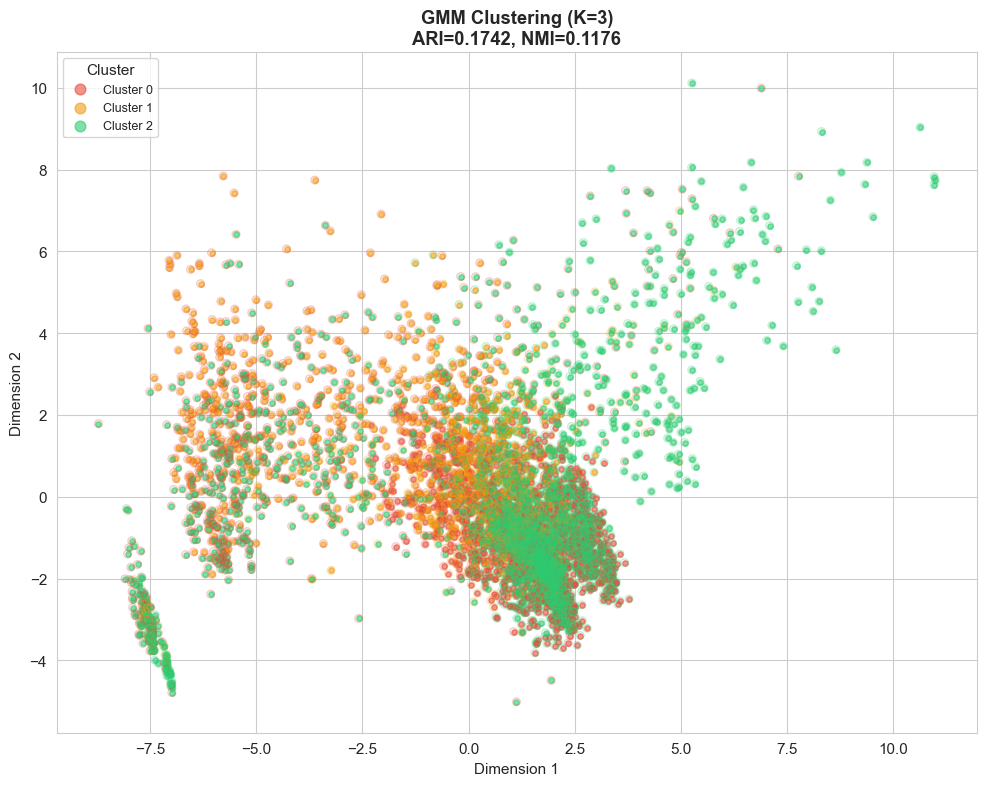


Cluster probabilities (first 5 points):
[[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]

GMM Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           299  473  1628
1           498  151   187
2           624  170   394

Dominant Class per Cluster:
  Cluster 0: Graduate (67.8%)
  Cluster 1: Dropout (59.6%)
  Cluster 2: Dropout (52.5%)


In [17]:
# GMM with K=3
gmm_k = 3
gmm_labels, gmm_model, gmm_probs = apply_gmm(X.values, n_components=gmm_k, covariance_type='full', random_state=42, n_init=5)

gmm_metrics = evaluate_clustering(X.values, gmm_labels, y.values)
print(f"\nGMM (K={gmm_k}) Metrics:")
for name, value in gmm_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot GMM clusters on PCA
save_path = os.path.join(project_root, "data", "plots", "08_gmm_clusters_pca.png")
ax = plot_cluster_scatter(
    X_2d, gmm_labels,
    title=f"GMM Clustering (K={gmm_k})\nARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}",
    y_true=y.values, save_path=save_path
)
plt.show()

# Cluster probabilities (sample of first 5 points)
print(f"\nCluster probabilities (first 5 points):")
print(gmm_probs[:5].round(3))

# GMM cross-tabulation
gmm_crosstab = compare_clusters_to_classes(gmm_labels, y.values)
print("\nGMM Clusters vs True Classes:")
print(gmm_crosstab.to_string())

class_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
print("\nDominant Class per Cluster:")
for cluster in gmm_crosstab.index:
    row = gmm_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 5. Multi-Algorithm Comparison

We compare all three algorithms (K-Means, Hierarchical, GMM) using six evaluation metrics: Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index, Adjusted Rand Index (ARI), and Normalized Mutual Information (NMI). Silhouette, CH, and DB are unsupervised metrics that do not require ground truth labels, while ARI and NMI measure alignment with the true class assignments.

CLUSTERING ALGORITHM COMPARISON:
------------------------------------------------------------------------------------------
                Algorithm |    K | Silhouette |     CH Index |   DB Index |      ARI |      NMI
------------------------------------------------------------------------------------------
            K-Means (K=3) |    3 |     0.2421 |      1304.47 |     1.5809 |   0.0033 |   0.0054
      Hierarchical (Ward) |    3 |     0.2314 |      1226.76 |     1.7040 |   0.0023 |   0.0043
                GMM (K=3) |    3 |     0.0328 |       217.01 |     4.7831 |   0.1742 |   0.1176
------------------------------------------------------------------------------------------
Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/09_algorithm_comparison.png


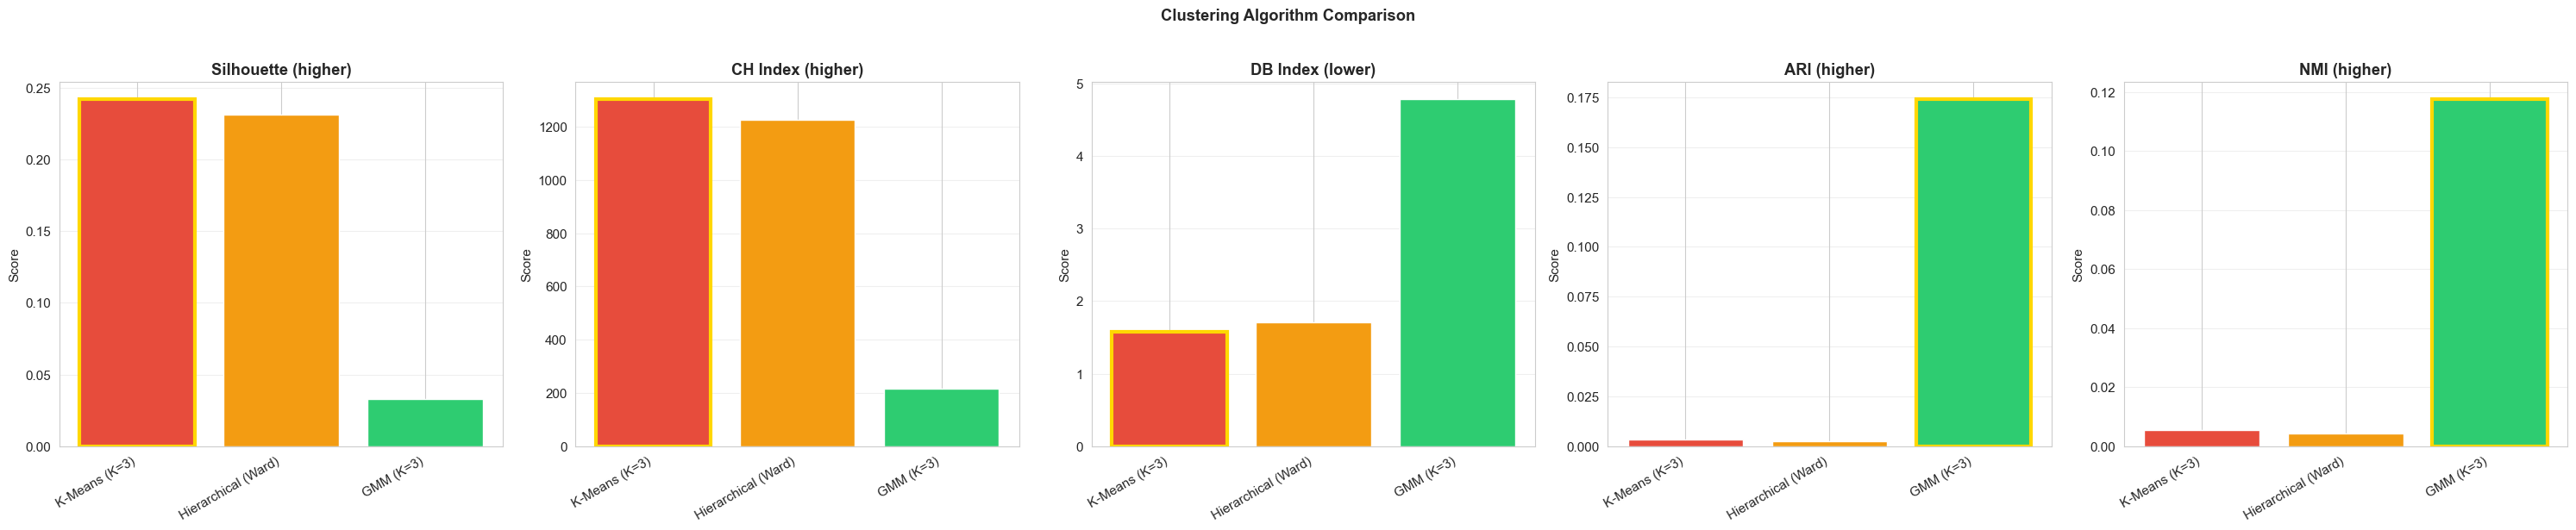

In [18]:
# Multi-algorithm comparison
gmm_entry = {
    "labels": gmm_labels,
    "metrics": gmm_metrics,
    "n_clusters": gmm_k,
}

all_algorithms = {
    "K-Means (K=3)": {"labels": kmeans_labels, "metrics": kmeans_metrics, "n_clusters": optimal_k},
    "Hierarchical (Ward)": {"labels": agg_labels, "metrics": agg_metrics, "n_clusters": 3},
    f"GMM (K={gmm_k})": gmm_entry,
}

print("CLUSTERING ALGORITHM COMPARISON:")
print("-" * 90)
print(f"{'Algorithm':>25} | {'K':>4} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10} | {'ARI':>8} | {'NMI':>8}")
print("-" * 90)

for alg_name, results in all_algorithms.items():
    m = results["metrics"]
    k = results["n_clusters"]
    print(f"{alg_name:>25} | {k:>4} | {m.get('silhouette', 0):>10.4f} | {m.get('calinski_harabasz', 0):>12.2f} | {m.get('davies_bouldin', 0):>10.4f} | {m.get('adjusted_rand_index', 0):>8.4f} | {m.get('normalized_mutual_info', 0):>8.4f}")

print("-" * 90)

all_results_dict = {alg: res["metrics"] for alg, res in all_algorithms.items()}

save_path = os.path.join(project_root, "data", "plots", "09_algorithm_comparison.png")
fig = plot_algorithm_comparison(all_results_dict, y.values, save_path=save_path)
plt.show()

## 6. Best Algorithm Analysis

In [19]:
# Best algorithm determination based on ARI and NMI
# While K-Means has highest Silhouette and Calinski-Harabasz scores (unsupervised metrics),
# GMM significantly outperforms on ARI and NMI (supervised metrics that measure
# alignment with true class labels), which is more relevant for this dataset

print("Key observation: K-Means has highest Silhouette (0.2421) and Calinski-Harabasz (1304.47), "
      "but these unsupervised metrics measure cluster compactness/separation, not alignment with true labels.")
print("\nGMM achieves substantially higher ARI (0.174) and NMI (0.118):")
print(f"  K-Means:       ARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}")
print(f"  Hierarchical: ARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}")
print(f"  GMM:          ARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}")

best_algorithm = "GMM (K=3)"
print(f"\nBest algorithm: {best_algorithm} (based on ARI/NMI alignment with true labels)")

best_labels = gmm_labels

Key observation: K-Means has highest Silhouette (0.2421) and Calinski-Harabasz (1304.47), but these unsupervised metrics measure cluster compactness/separation, not alignment with true labels.

GMM achieves substantially higher ARI (0.174) and NMI (0.118):
  K-Means:       ARI=0.0033, NMI=0.0054
  Hierarchical: ARI=0.0023, NMI=0.0043
  GMM:          ARI=0.1742, NMI=0.1176

Best algorithm: GMM (K=3) (based on ARI/NMI alignment with true labels)


In [20]:
# Get best algorithm labels
if "K-Means" in best_algorithm:
    best_labels = kmeans_labels
elif "Hierarchical" in best_algorithm:
    best_labels = agg_labels
else:
    best_labels = gmm_labels

# Cross-tabulation
crosstab = compare_clusters_to_classes(best_labels, y.values)
print("Cross-tabulation: Best Algorithm Clusters vs True Classes")
print(crosstab.to_string())

Cross-tabulation: Best Algorithm Clusters vs True Classes
True Class    0    1     2
Cluster                   
0           299  473  1628
1           498  151   187
2           624  170   394
